In [5]:
import pandas as pd
df_sprint1 = pd.read_csv('/project_data/data_asset/op_analysis_07012019_09302019.csv')
df_sprint1.head()


,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000


In [1]:
import pandas as pd
df_data_1 = pd.read_csv('/project_data/data_asset/revised_op_analysis_01012019_03312019.csv')

df_data_2 = pd.read_csv('/project_data/data_asset/revised_op_analysis_04012019_06302019.csv')

df_data_3 = pd.read_csv('/project_data/data_asset/revised_op_analysis_07012019_09302019.csv')

df_data_4 = pd.read_csv('/project_data/data_asset/revised_op_analysis_10012019_12312019.csv')


frames = [df_data_1, df_data_1, df_data_1, df_data_1]

df_sprint1 = pd.concat(frames)

In [2]:
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,...,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,1,1,28.0,2019-01-11,2019-01-11,122110,1,1.000000,28.000000,1.000000,...,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.000000
1,174,616,50866.0,2019-03-31,2019-01-01,165027,90,3.540230,292.333333,6.844444,...,0.086207,616,0.0,0.0,0.367816,0.0,0.0,0.224138,0,0.005747
2,4,25,997.0,2019-03-26,2019-01-01,118005,85,6.250000,249.250000,0.294118,...,0.000000,4,0.0,0.0,0.250000,0.0,0.0,0.250000,0,0.000000
3,7,18,1771.0,2019-03-31,2019-01-09,25176,82,2.571429,253.000000,0.219512,...,0.000000,3,0.0,0.0,0.000000,0.0,0.0,0.142857,0,0.000000
4,4,8,258.0,2019-03-19,2019-01-04,114836,75,2.000000,64.500000,0.106667,...,0.000000,2,0.0,0.0,0.500000,0.0,0.0,0.750000,0,0.000000


In [3]:
# import some libraries into the notebook
# all these libraries are pre-installed in Cloud Pak for Data

import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
import sys

from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import seaborn as sns
import matplotlib.pyplot as plt
#from matplotlib.pyplot import figure
%matplotlib inline

In [41]:
df_sprint1.describe()

,Member Count,Count Script,Sum Dispensed Quantity,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
count,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.0,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.000000,53804.0,53804.000000,53804.000000
mean,9.628578,19.651922,987.239284,115092.600922,53.064456,1.644281,71.407807,0.455136,18.149324,0.154945,0.043307,0.386142,0.000088,0.000562,0.030932,0.395505,0.100651,0.0,0.000818,0.001192,0.022231,1.809382,0.033749,0.001369,0.048937,0.001923,0.000014,0.213664,0.0,0.001574,2.962828
std,17.255610,50.420263,3431.736901,41130.222041,32.130710,0.907373,84.276360,0.640307,42.209054,0.208599,0.166002,1.986561,0.001397,0.015891,0.105009,0.379072,0.172486,0.0,0.028585,0.018286,0.088116,11.682997,0.156772,0.022974,0.137956,0.024973,0.000805,0.281536,0.0,0.021977,2.132803
min,1.000000,1.000000,0.500000,9.000000,1.000000,1.000000,0.500000,0.022472,0.044444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,2.000000,2.000000,50.000000,106878.000000,24.000000,1.000000,17.550000,0.102041,2.453488,0.020219,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
50%,4.000000,6.000000,180.000000,120740.000000,65.000000,1.285714,42.500000,0.200000,6.545455,0.074534,0.000000,0.000000,0.000000,0.000000,0.000000,0.309524,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.0,0.000000,4.000000
75%,10.000000,17.000000,669.000000,139874.000000,82.000000,2.000000,96.000000,0.712644,18.352941,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.750000,0.180000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.0,0.000000,5.000000
max,287.000000,1521.000000,138235.000000,170962.000000,90.000000,12.250000,1780.000000,17.089888,1553.202247,1.000000,1.000000,75.000000,0.142857,1.000000,1.000000,1.000000,0.900000,0.0,1.000000,1.000000,1.000000,616.000000,1.000000,1.000000,1.000000,1.000000,0.062500,1.000000,0.0,1.000000,5.000000


In [40]:
df_sprint1['Cluster_label'].describe()

count    53804.000000
mean         2.962828
std          2.132803
min          0.000000
25%          0.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Cluster_label, dtype: float64

In [5]:
df_sprint1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53804 entries, 0 to 13450
Data columns (total 32 columns):
Member Count              53804 non-null int64
Count Script              53804 non-null int64
Sum Dispensed Quantity    53804 non-null float64
Max Dispense Date         53804 non-null object
Min Dispense Date         53804 non-null object
PRSCRB_PROV_LOC_ID        53804 non-null int64
Total Days                53804 non-null int64
PR2                       53804 non-null float64
PR1                       53804 non-null float64
PR4                       53804 non-null float64
PR3                       53804 non-null float64
PR5                       53804 non-null float64
PR6                       53804 non-null float64
PR7                       53804 non-null int64
PR8                       53804 non-null float64
PR9                       53804 non-null float64
PR10                      53804 non-null float64
PR11                      53804 non-null float64
PR13                 

In [6]:
df_sprint1.shape

(53804, 32)

In [7]:
# make lists of indicies and features for preprocessing pipeline

to_drop = []
index = ['PRSCRB_PROV_LOC_ID', 'Max Dispense Date', 'Min Dispense Date']
features = [c for c in df_sprint1.columns if c not in index or to_drop]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [8]:
# redefine columns

features = [c for c in df_sprint1.columns if c not in to_drop+index]
num_features = df_sprint1[features].select_dtypes('number').columns.tolist()

In [9]:
num_features

['Member Count',
 'Count Script',
 'Sum Dispensed Quantity',
 'Total Days',
 'PR2',
 'PR1',
 'PR4',
 'PR3',
 'PR5',
 'PR6',
 'PR7',
 'PR8',
 'PR9',
 'PR10',
 'PR11',
 'PR13',
 'PR15',
 'PR18',
 'PR19',
 'PR21',
 'PR22',
 'PR23',
 'PR24',
 'PR25',
 'PR26',
 'PR27',
 'PR28',
 'PR29',
 'PR30']

In [10]:
# define a preprocessor
# handle scaling and imputation

def preprocessor_sprint1(list_of_numerical_features):
    '''
    num_features is a python list of numerical features
    '''
    scaler = StandardScaler() # use robust or standard
    
    numerical_pipeline = make_pipeline(SimpleImputer(strategy='mean'), scaler)
    
    preprocessor = make_column_transformer((numerical_pipeline, list_of_numerical_features), remainder='drop')
    
    return preprocessor

In [11]:
# call the preprocessor
# see that the preprocessor is working
preprocessor_sprint1_regen = preprocessor_sprint1(num_features)

tmp = preprocessor_sprint1_regen.transformers[0][1].fit_transform(df_sprint1[num_features])
df_sprint1_processed = pd.DataFrame(data=tmp, columns=[c for c in num_features if df_sprint1[c].isna().all()==False], index=df_sprint1.index)
df_sprint1_processed.head()

,Member Count,Count Script,Sum Dispensed Quantity,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,-0.500049,-0.369933,-0.279523,-1.620411,-0.710057,-0.515070,0.850949,0.233380,1.654171,5.763204,-0.194379,-0.062877,-0.035368,-0.294572,-1.043361,-0.583539,0.0,-0.028609,-0.065166,-0.252296,-0.154875,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.758930,0.0,-0.071636
1,9.525769,11.827658,14.534688,1.149551,2.089512,2.621466,9.978598,12.960099,1.348766,-0.157022,24.471590,-0.062877,-0.035368,1.128416,1.256366,0.807893,0.0,-0.028609,-0.065166,0.726051,52.571814,-0.215277,-0.059603,2.311474,-0.076997,-0.017072,0.037204,0.0,0.189874
2,-0.326191,0.106071,0.002844,0.993935,5.075930,2.110246,-0.251473,-0.152099,-0.656572,-0.260885,0.309008,-0.062877,-0.035368,4.466964,-1.043361,1.735514,0.0,-0.028609,-0.065166,-0.252296,0.187507,-0.215277,-0.059603,1.457455,-0.076997,-0.017072,0.129066,0.0,-0.071636
3,-0.152333,-0.032763,0.228388,0.900566,1.021803,2.154743,-0.367989,0.081695,-0.499034,-0.260885,-0.194379,-0.062877,-0.035368,1.065867,0.568780,1.039798,0.0,-0.028609,-0.065166,-0.252296,0.101911,-0.215277,-0.059603,-0.354732,-0.076997,-0.017072,-0.251504,0.0,-0.071636
4,-0.326191,-0.231098,-0.212501,0.682703,0.392036,-0.081967,-0.544228,-0.348491,0.782548,-0.260885,0.309008,-0.062877,-0.035368,-0.294572,0.935175,-0.583539,0.0,-0.028609,-0.065166,-0.252296,0.016316,-0.215277,-0.059603,3.269641,-0.076997,-0.017072,1.905056,0.0,-0.071636


In [12]:
pca = PCA()
X_pca = pca.fit(df_sprint1_processed)

Text(0, 0.5, 'cumulative explained variance')

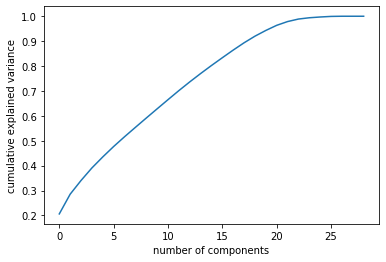

In [13]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

In [14]:
pca = PCA(n_components = 0.75)
X_pca = pca.fit_transform(df_sprint1_processed)
print(pca.n_components_)

14


In [15]:
n_pcs= pca.n_components_ # get number of component
# get the index of the most important feature on EACH component
most_important = [np.abs(pca.components_[i]).argmax() for i in range(n_pcs)]
initial_feature_names = df_sprint1_processed.columns
# get the most important feature names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

In [16]:
print(most_important_names)

['Count Script', 'PR2', 'PR28', 'PR6', 'PR5', 'PR26', 'PR30', 'PR18', 'PR9', 'PR27', 'PR27', 'PR9', 'PR23', 'PR6']


In [17]:
var = pca.explained_variance_ratio_
print(var)

[0.2062203  0.07923232 0.05501279 0.05035164 0.04427526 0.0417903
 0.03916808 0.03772939 0.03740351 0.03700443 0.03679038 0.03637489
 0.03497056 0.03354853]


Text(0, 0.5, 'Explained Variance Ratio')

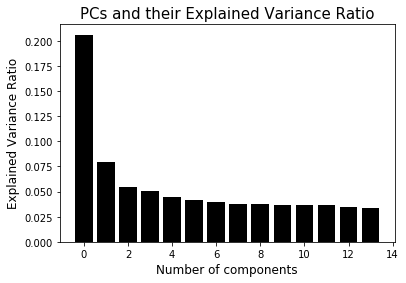

In [18]:
#Plot explained variance ratio for each PC
plt.bar([i for i, _ in enumerate(var)],var,color='black')
plt.title('PCs and their Explained Variance Ratio', fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Explained Variance Ratio',fontsize=12)

In [19]:
#Cumulative Variance explained by each PC
cum_var = np.cumsum(np.round(pca.explained_variance_ratio_, decimals=4)*100)
print(cum_var)

[20.62 28.54 34.04 39.08 43.51 47.69 51.61 55.38 59.12 62.82 66.5  70.14
 73.64 76.99]


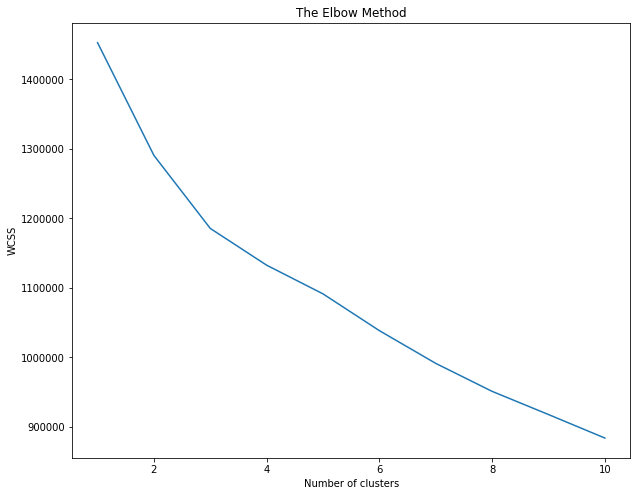

In [20]:
# find the appropriate cluster number
plt.figure(figsize=(10, 8))
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_sprint1_processed)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Hierarchical clustering for the same dataset
# creating a dataset for hierarchical clustering
dataset2_standardized = df_sprint1_processed
# needed imports
from scipy.cluster.hierarchy import dendrogram, linkage

# some setting for this notebook to actually show the graphs inline
# you probably won't need this
%matplotlib inline
np.set_printoptions(precision=6, suppress=True)  # suppress scientific float notation
#creating the linkage matrix
H_cluster = linkage(dataset2_standardized,'ward')
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('sample index or (cluster size)')
plt.ylabel('distance')
dendrogram(
    H_cluster,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=5,  # show only the last p merged clusters
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,  # to get a distribution impression in truncated branches
)
plt.show()

Text(0, 0.5, 'Cumulative Explained Variance Ratio')

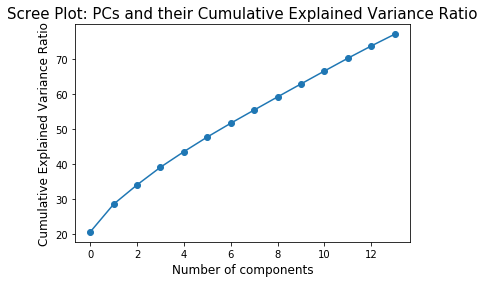

In [21]:
# Scree Plot
plt.plot(cum_var, marker='o')
plt.title('Scree Plot: PCs and their Cumulative Explained Variance Ratio',fontsize=15)
plt.xlabel('Number of components',fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio',fontsize=12)

In [22]:
#Fitting data into K-Means model with 5 clusters
km_5=KMeans(n_clusters=5,random_state=12345)
km_5.fit(df_sprint1_processed)
print(km_5.cluster_centers_)

[[-4.80598649e-01 -3.60996057e-01 -2.75637577e-01 -1.56587088e+00
  -6.21798959e-01 -4.80006865e-01  7.45436466e-01  2.08544678e-01
   7.34531383e-02  7.41019048e-02 -1.84294786e-01  9.20425987e-03
   3.17990762e-02 -1.08836946e-01  5.71274832e-02 -5.80397474e-01
   0.00000000e+00  5.85752576e-03 -6.51660513e-02 -2.33316855e-02
  -1.37952282e-01  1.09196700e-01 -5.10259929e-02 -4.48022799e-02
  -2.60388524e-02 -1.70720794e-02 -2.40660652e-02  0.00000000e+00
  -7.16355217e-02]
 [ 3.94520536e-01  3.09010820e-01  2.31200076e-01  8.47781455e-01
   9.00651505e-01  7.98027666e-01 -4.45963757e-02  8.27591661e-02
  -2.27973229e-02 -2.98126774e-02  1.33111875e-01  2.37544873e-02
   1.10572444e-02  2.30231484e-01 -3.15900464e-01  1.25667639e+00
   0.00000000e+00  1.16018812e-02 -7.17732056e-03  7.15937913e-02
   6.72304131e-02 -1.25456359e-01  2.06529261e-02  1.21674649e-01
   5.43503323e-02 -1.70720794e-02 -1.31548904e-01  0.00000000e+00
   1.58051892e-01]
 [-2.21437105e-01 -2.41122084e-01 -2.2

In [23]:
pd.Series(km_5.labels_).value_counts()

2    26280
1    13916
0    12180
4     1296
3      132
dtype: int64

In [24]:
from sklearn import metrics
metrics.silhouette_score(df_sprint1_processed, km_5.labels_)

0.13995432251769735

In [25]:
# calculate SC for K=2 through K=10
k_range = range(2, 10)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=12345)
    km.fit(df_sprint1_processed)
    scores.append(metrics.silhouette_score(df_sprint1_processed, km.labels_))

In [26]:
print(scores)

[0.7050760034633294, 0.19381372554101398, 0.2134413624585537, 0.13995432251769735, 0.12669170434357233, 0.18576754980868498, 0.1549505846051247, 0.15753262113173386]


In [ ]:
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples
sse,db,slc = {}, {}, {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000,random_state=12345).fit(df_sprint1_processed)
    if k == 4: labels = kmeans.labels_
    clusters = kmeans.labels_
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    db[k] = davies_bouldin_score(df_sprint1_processed,clusters)
    slc[k] = silhouette_score(df_sprint1_processed,clusters)

In [ ]:
#Plotting SSE
plt.figure(figsize=(12,6))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("SSE (Sum of Squared Errors)", fontsize=12)
plt.title("Sum of Squared Errors vs No. of Clusters", fontsize=15)
plt.show()

In [ ]:
#Plotting Davies-Bouldin Scores
plt.figure(figsize=(12,6))
plt.plot(list(db.keys()), list(db.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Davies-Bouldin values", fontsize=12)
plt.title("Davies-Bouldin Scores vs No. of Clusters", fontsize=15)
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(list(slc.keys()), list(slc.values()))
plt.xlabel("Number of cluster", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs No. of Clusters", fontsize=15)
plt.show()

In [27]:
df_sprint1_processed2 = df_sprint1_processed

In [28]:
# start will the maximum number of components
# this helps to show us all the variance per component

pca = PCA(n_components=df_sprint1_processed2.shape[1]) #Initialize PCA with components = number variables in preprocessed dataframe
tmp_pca = pca.fit_transform(df_sprint1_processed2) #Call fit_transform method to apply PCA

# now we have the same result as we had in Sprint 1
# this can be read as, "First component explains 35.5% of variance in the data, second component explains 17.8% of variance in the data, ..."
# I will choose the first 3 to keep things simple and make clustering easily visual

pca.explained_variance_ratio_

array([2.06220296e-01, 7.92323198e-02, 5.50127874e-02, 5.03516422e-02,
       4.42752613e-02, 4.17902957e-02, 3.91680768e-02, 3.77293935e-02,
       3.74035096e-02, 3.70044327e-02, 3.67903835e-02, 3.63748852e-02,
       3.49705630e-02, 3.35485261e-02, 3.23536997e-02, 3.12284016e-02,
       3.06955724e-02, 2.92872631e-02, 2.65192632e-02, 2.30243029e-02,
       2.05461649e-02, 1.50910911e-02, 1.01017255e-02, 5.19085105e-03,
       3.06654636e-03, 2.35413686e-03, 6.68608124e-04, 1.22947147e-33,
       1.22947146e-33])

In [29]:
# the variable `num_components_tokeep` can be changed to include more or less components for the clustering
# using the variable makes it easier for us to change if we want

num_components_tokeep = 6
df_for_clustering = pd.DataFrame(data=tmp_pca[:,:num_components_tokeep], columns=[(f'Comp {c}') for c in range(1,num_components_tokeep+1)], index=df_sprint1_processed2.index)
df_for_clustering.head()

,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5,Comp 6
0,-0.870262,1.263912,-0.233421,3.762805,0.446680,0.255612
1,42.310127,13.790154,0.108484,0.199508,4.861532,-2.243793
2,2.253227,-5.391136,1.827894,1.243232,-1.613333,0.960802
3,0.892132,-2.272500,0.280157,-0.392223,-1.057466,-0.130932
4,-0.259375,-0.298338,2.375812,0.300776,1.367829,-1.111135


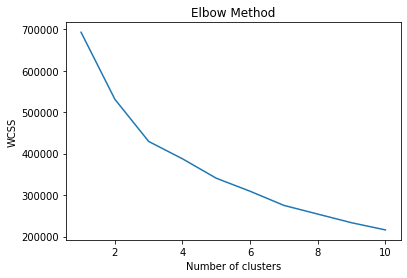

In [30]:
# make the Elbow Plot to see what is the ideal number of clusters

wcss = [] # within cluster sum of squares (sum of squared distance to cluster centroid)
for i in range(1, 11):
    #run k-means for clusters 1 - 11
    kmeans = KMeans(n_clusters=i, init='random', max_iter=300, n_init=10, random_state=12) 
    kmeans.fit(df_for_clustering)
    wcss.append(kmeans.inertia_) #inertia = wcss
plt.plot(range(1, 11), wcss)
#The elbow point indicates the number of clusters at which we've explained much of the variation in the
# reduced dataset without separating the data too much (with each observation being assigned to their own cluster 
# being maximum number of clusters and pretty pointless)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [31]:
# IMO, 4 is the ideal number of clusters, so that is how many i will use
number_of_clusters = 6

kmeans = KMeans(n_clusters=number_of_clusters, random_state=12) # make the clustering
kmeans.fit(df_for_clustering) # fit the clustering to the data
y_kmeans = kmeans.predict(df_for_clustering) # predict to get the labels

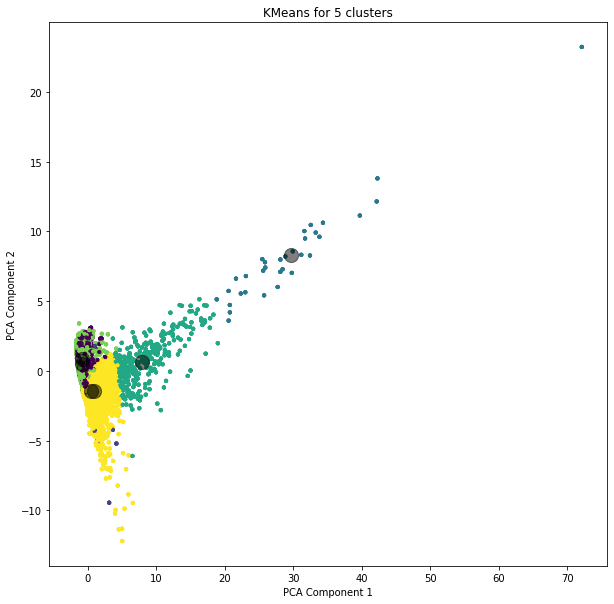

In [32]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 1], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show();

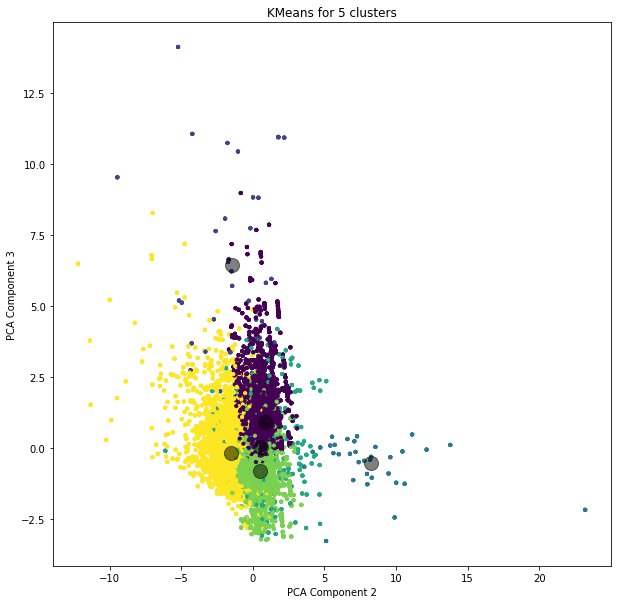

In [33]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 1], df_for_clustering.iloc[:, 2], c=y_kmeans, s=10, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 2')
plt.ylabel('PCA Component 3')
plt.show();

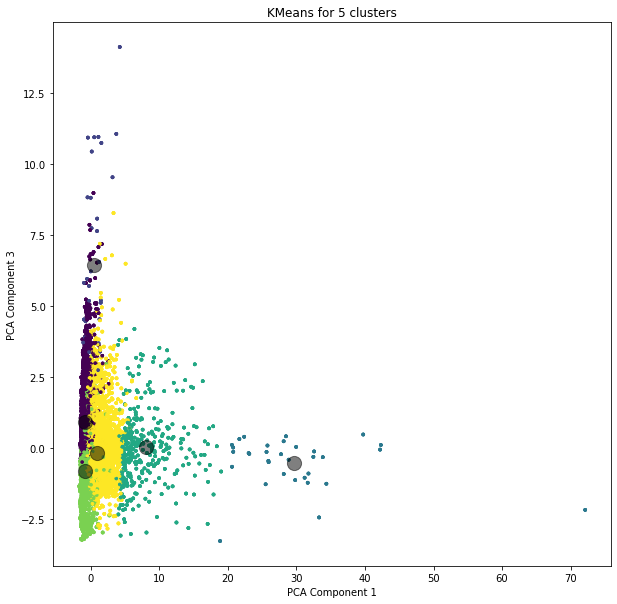

In [34]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 2], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 3')

plt.show();

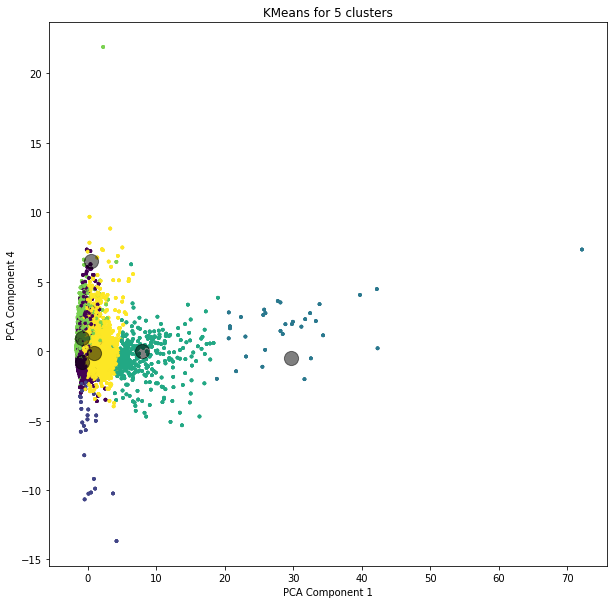

In [35]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 3], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 4')

plt.show();

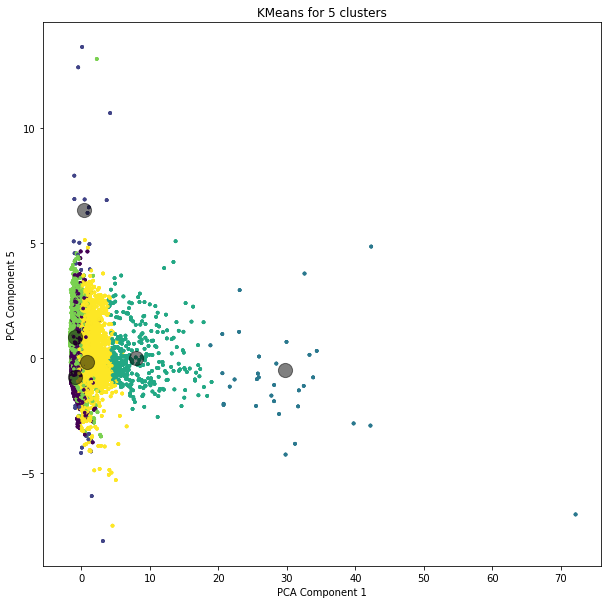

In [36]:
plt.figure(figsize=(10,10))
plt.scatter(df_for_clustering.iloc[:, 0], df_for_clustering.iloc[:, 4], c=y_kmeans, s=7, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 2], c='black', s=200, alpha=0.5)
plt.title('KMeans for 5 clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 5')

plt.show();

In [37]:
# calculate silhouette score of this clustering algorithm
sil_score = round(silhouette_score(df_for_clustering, y_kmeans), 3)
print(f'Silhouette score for 6 clusters is {sil_score}')

Silhouette score for 6 clusters is 0.224


In [38]:
df_sprint1['Cluster_label'] = pd.Series(y_kmeans, index=df_sprint1.index)
df_sprint1.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,1,1,28.0,2019-01-11,2019-01-11,122110,1,1.000000,28.000000,1.000000,28.000000,0.500000,1.000000,0,0.0,0.0,0.000000,0.000000,0.00,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0,0.000000,4
1,174,616,50866.0,2019-03-31,2019-01-01,165027,90,3.540230,292.333333,6.844444,565.177778,0.436293,0.017241,49,0.0,0.0,0.149425,0.871753,0.24,0,0,0.0,0.086207,616,0.0,0.0,0.367816,0.0,0.0,0.224138,0,0.005747,2
2,4,25,997.0,2019-03-26,2019-01-01,118005,85,6.250000,249.250000,0.294118,11.729412,0.017986,0.000000,1,0.0,0.0,0.500000,0.000000,0.40,0,0,0.0,0.000000,4,0.0,0.0,0.250000,0.0,0.0,0.250000,0,0.000000,5
3,7,18,1771.0,2019-03-31,2019-01-09,25176,82,2.571429,253.000000,0.219512,21.597561,0.050847,0.000000,0,0.0,0.0,0.142857,0.611111,0.28,0,0,0.0,0.000000,3,0.0,0.0,0.000000,0.0,0.0,0.142857,0,0.000000,5
4,4,8,258.0,2019-03-19,2019-01-04,114836,75,2.000000,64.500000,0.106667,3.440000,0.318182,0.000000,1,0.0,0.0,0.000000,0.750000,0.00,0,0,0.0,0.000000,2,0.0,0.0,0.500000,0.0,0.0,0.750000,0,0.000000,0


In [39]:
pd.Series(y_kmeans).value_counts()

0    17660
4    17600
5    16896
3     1376
1      140
2      132
dtype: int64

In [89]:
df_sprint2 = pd.read_csv('/project_data/data_asset/op_analysis_01012019_03312019.csv')
df_sprint2.head()
df_sprint3 = pd.read_csv('/project_data/data_asset/op_analysis_04012019_06302019.csv')
df_sprint3.head()
df_sprint5 = pd.read_csv('/project_data/data_asset/op_analysis_10012019_12312019.csv')
df_sprint5.head()
df_sprint4 = pd.read_csv('/project_data/data_asset/op_analysis_07012019_09302019.csv')
df_sprint4.head()

,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR22,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30
0,3,5,120.0,2019-09-30,2019-08-25,158757,37,1.666667,40.000000,0.135135,3.243243,0.040816,0.000000,0,0.0,0.0,0.000000,0.000000,0.924242,0,0,0.0,0.000000,0,0.0,0.0,0.000000,0.0,0.000000,0.333333,0,0.000000
1,177,439,32077.0,2019-09-30,2019-07-01,2755,92,2.480226,181.225989,4.771739,348.663043,0.295775,0.011299,22,0.0,0.0,0.039007,0.241458,0.670420,0,0,0.0,0.079096,35,0.0,0.0,0.118644,0.0,0.016949,0.163842,0,0.022599
2,67,177,8075.0,2019-09-30,2019-07-01,157094,92,2.641791,120.522388,1.923913,87.771739,0.051329,0.000000,0,0.0,0.0,0.026144,0.045198,0.822467,0,0,0.0,0.000000,6,0.0,0.0,0.000000,0.0,0.000000,0.208955,0,0.000000
3,6,9,290.0,2019-09-28,2019-08-01,163295,59,1.500000,48.333333,0.152542,4.915254,0.083333,0.000000,0,0.0,0.0,0.000000,0.333333,0.923729,0,0,0.0,0.166667,0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0,0.000000
4,36,82,4219.0,2019-09-30,2019-07-01,112047,92,2.277778,117.194444,0.891304,45.858696,0.039152,0.000000,1,0.0,0.0,0.011429,0.292683,0.864238,0,0,0.0,0.000000,0,0.0,0.0,0.083333,0.0,0.000000,0.111111,0,0.000000


In [84]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['153504', '139433', '17522', '16638'])])

      Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        2019-03-31   
5043           188           913                 78274.0        2019-03-30   
6751           163           573                 49093.0        2019-03-31   
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        2019-03-31   
5043           188           913                 78274.0        2019-03-30   
6751           163           573                 49093.0        2019-03-31   
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        2019-03-31   
5043           188           913                 78274.0        2019-03-30   
6751           163           573                 49093.0        

In [49]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485', 
                                                            '110160', '117265', '107410', '152853', '154518', '165594', '153504', '165027', '139433', '4457', '170094', '17522', '16638'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
1               174           616                 50866.0        2019-03-31   
18              218           689                 51519.0        2019-03-31   
46              174           706                 53425.0        2019-03-31   
49              167           737                 54424.0        2019-03-31   
294              30            47                  2741.0        2019-03-28   
1594              1             1                    40.0        2019-01-07   
1624            161           500                 42923.0        2019-03-31   
3310            175           830                 67091.0        2019-03-31   
5029            287          1521                138235.0        2019-03-31   
5043            188           913                 78274.0        2019-03-30   
5636              1             1                    60.0        2019-03-06   
6751            163           573                 49

In [85]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
46              174           706                 53425.0        2019-03-31   
49              167           737                 54424.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
11767            78            90                  2658.0        2019-02-06   
46              174           706                 53425.0        2019-03-31   
49              167           737                 54424.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
11767            78            90                  2658.0        2019-02-06   
46              174           706                 53425.0        2019-03-31   
49              167           737                 54424.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
11767            78            90                  2

In [86]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['110160', '117265', '107410', '152853'])])

      Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
18             218           689                 51519.0        2019-03-31   
294             30            47                  2741.0        2019-03-28   
1594             1             1                    40.0        2019-01-07   
7124             6             8                   840.0        2019-03-19   
18             218           689                 51519.0        2019-03-31   
294             30            47                  2741.0        2019-03-28   
1594             1             1                    40.0        2019-01-07   
7124             6             8                   840.0        2019-03-19   
18             218           689                 51519.0        2019-03-31   
294             30            47                  2741.0        2019-03-28   
1594             1             1                    40.0        2019-01-07   
7124             6             8                   840.0        

In [87]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['154518', '165594', '153504', '165027'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
1               174           616                 50866.0        2019-03-31   
1624            161           500                 42923.0        2019-03-31   
6751            163           573                 49093.0        2019-03-31   
11753           219           672                 55098.0        2019-03-30   
1               174           616                 50866.0        2019-03-31   
1624            161           500                 42923.0        2019-03-31   
6751            163           573                 49093.0        2019-03-31   
11753           219           672                 55098.0        2019-03-30   
1               174           616                 50866.0        2019-03-31   
1624            161           500                 42923.0        2019-03-31   
6751            163           573                 49093.0        2019-03-31   
11753           219           672                 55

In [88]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['139433', '4457', '170094', '17522', '16638'])])

      Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        2019-03-31   
5043           188           913                 78274.0        2019-03-30   
5636             1             1                    60.0        2019-03-06   
6841           206           663                 57966.0        2019-03-31   
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        2019-03-31   
5043           188           913                 78274.0        2019-03-30   
5636             1             1                    60.0        2019-03-06   
6841           206           663                 57966.0        2019-03-31   
3310           175           830                 67091.0        2019-03-31   
5029           287          1521                138235.0        

In [67]:
print(df_sprint1.loc[df_sprint1['PRSCRB_PROV_LOC_ID'].isin(['101075', '110876', '111813', '139433', '149990', '153826', '153997'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3310            175           830                 67091.0        2019-03-31   
10114           164           695                 46550.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
10856             6             6                   840.0        2019-03-27   
3310            175           830                 67091.0        2019-03-31   
10114           164           695                 46550.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
10856             6             6                   840.0        2019-03-27   
3310            175           830                 67091.0        2019-03-31   
10114           164           695                 46550.0        2019-03-31   
10229           162           474                 37033.5        2019-03-31   
10856             6             6                   

In [102]:
df = pd.read_csv('/project_data/data_asset/op_analysis_with_nulls_with_labels.csv')
df.head()


,Member Count,Count Script,Sum Dispensed Quantity,Max Dispense Date,Min Dispense Date,PRSCRB_PROV_LOC_ID,Total Days,PR2,PR1,PR4,PR3,PR5,PR6,PR7,PR8,PR9,PR10,PR11,PR13,PR15,PR18,PR19,PR21,PR23,PR24,PR25,PR26,PR27,PR28,PR29,PR30,Cluster_label
0,7,7,301.0,2020-03-30,2020-01-25,130843,66,1.000000,43.000000,0.106061,4.560606,0.048077,NaN,NaN,NaN,NaN,NaN,1.000000,0.860000,NaN,NaN,NaN,NaN,0.5,NaN,0.142857,NaN,NaN,0.285714,NaN,NaN,0
1,11,24,778.0,2020-03-31,2020-01-02,107152,90,2.181818,70.727273,0.266667,8.644444,0.231405,NaN,NaN,NaN,NaN,NaN,0.375000,0.862857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,9,16,391.0,2020-03-31,2020-01-06,128217,86,1.777778,43.444444,0.186047,4.546512,0.062500,NaN,NaN,NaN,NaN,0.044444,0.937500,0.928571,NaN,NaN,NaN,0.222222,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,21,22,399.0,2020-03-26,2020-01-01,106985,86,1.047619,19.000000,0.255814,4.639535,0.220930,NaN,NaN,NaN,NaN,0.022222,0.909091,0.676471,NaN,NaN,NaN,0.047619,NaN,NaN,0.047619,NaN,NaN,0.333333,NaN,NaN,1
4,11,20,711.0,2020-03-26,2020-01-07,171977,80,1.818182,64.636364,0.250000,8.887500,0.695652,NaN,NaN,NaN,NaN,0.090909,0.400000,0.636364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,NaN,NaN,4


In [103]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['156800', '122949', '111813', '148485', 
                '110160', '117265', '107410', '152853', '154518', '165594', '153504', '165027', '139433', '4457', '170094', '17522', '16638'])])

       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
19               86           151                 10909.0        2020-03-31   
185              16            24                  2072.0        2020-03-28   
212              22            46                  2709.0        2020-03-19   
649              15            20                  1425.0        2020-02-28   
1604            162           514                 45477.0        2020-03-31   
3311            135           691                 54426.0        2020-03-31   
4955            208           842                 68946.0        2020-03-31   
4956            296          1534                134140.0        2020-03-31   
4976            210           993                 82084.0        2020-03-31   
6608            144           583                 50783.0        2020-03-31   
6632            215           643                 55388.0        2020-03-31   
6637            158           623                 43

In [52]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['153504', '139433', '17522', '16638'])])

NameError: name 'df' is not defined

In [106]:
df['Cluster_label'].value_counts()

1    5223
0    5211
4    2041
3     693
2      71
Name: Cluster_label, dtype: int64

In [107]:
print(df.loc[df['PRSCRB_PROV_LOC_ID'].isin(['101075', '110876', '111813', '139433', '149990', '153826', '153997'])])


       Member Count  Count Script  Sum Dispensed Quantity Max Dispense Date  \
3311            135           691                 54426.0        2020-03-31   
10028            37           198                 14804.0        2020-03-31   
10187            21            33                  1820.0        2020-03-30   

      Min Dispense Date  PRSCRB_PROV_LOC_ID  Total Days       PR2         PR1  \
3311         2020-01-02              139433          90  5.118519  403.155556   
10028        2020-01-02              149990          90  5.351351  400.108108   
10187        2020-01-06              111813          85  1.571429   86.666667   

            PR4         PR3       PR5       PR6   PR7       PR8       PR9  \
3311   7.677778  604.733333  0.290662  0.037037  47.0       NaN  0.007752   
10028  2.200000  164.488889  0.430939       NaN  16.0  0.004246  0.025000   
10187  0.388235   21.411765  0.180328       NaN   1.0  0.003261       NaN   

           PR10      PR11      PR13  PR15  PR18  